# EDA: Distributions & Outliers 

## Learning Objectives

- Explain why EDA is a required first step before modeling.
- Perform univariate analysis using Seaborn histograms, box plots, and count plots.
- Detect outliers using the IQR method and decide how to handle them.

## Key Topics
* What EDA is and why it comes first
* Seaborn for statistical visualization
* Univariate analysis: histogram, box plot, count plot, KDE
* Outlier detection with the IQR method
### 4.1  What EDA Is and Why It Comes First
Exploratory Data Analysis (EDA) is the systematic process of understanding a dataset before modeling — its 
structure, distributions, relationships, and problems. It is not optional preliminary work; skipping it is the most 
common cause of failed ML projects, because a model can only be as good as the understanding behind it. EDA is 
where you catch the data problems that would otherwise silently corrupt every result downstream.


### 4.2  Seaborn: Statistical Visualization
Seaborn is built on top of Matplotlib and specializes in statistical plots — it produces attractive, informative charts 
with far less code, and works directly with Pandas DataFrames. It is the primary EDA visualization tool for this 
program.


In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
df= sns.load_dataset("diamonds")
df



,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


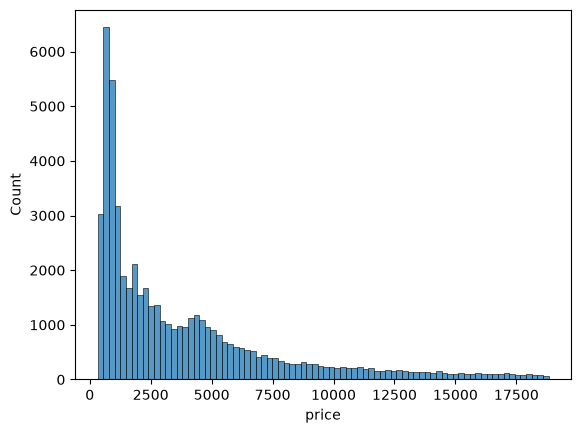

In [2]:

sns.histplot(data=df, x="price")
plt.show()


### 4.3 Univariate Analysis
Univariate analysis examines one variable at a time to understand its distribution. The core tools:

* Histogram 
* Box plot
* Count plot 
* KDE plot 

#### Histogram
  The shape of a numeric variable's distribution

Text(0.5, 1.0, 'carat distribution')

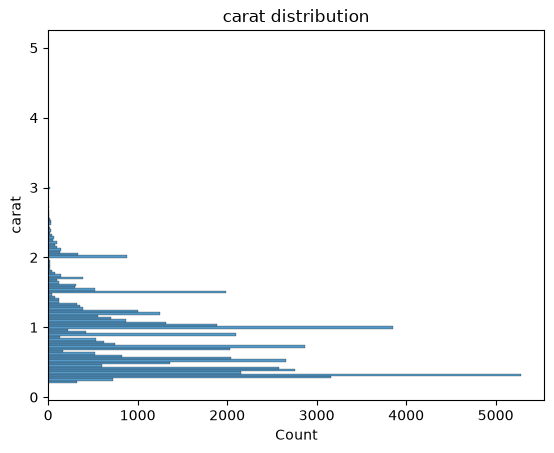

In [19]:
sns.histplot(df,y="carat")
plt.title("carat distribution")

#### Box plot 
To find  Median, quartiles, and outliers at a glance


<Axes: xlabel='price'>

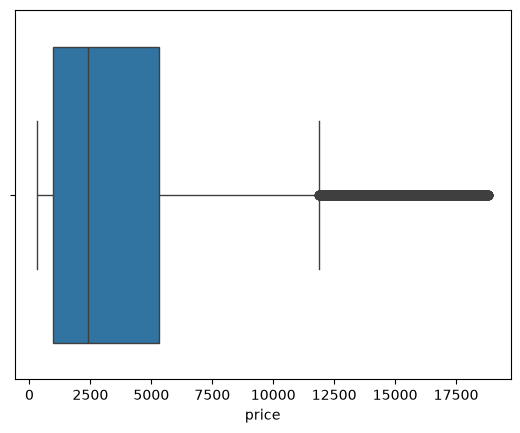

In [17]:
sns.boxplot(df,x="price")

In [5]:
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


<Axes: ylabel='depth'>

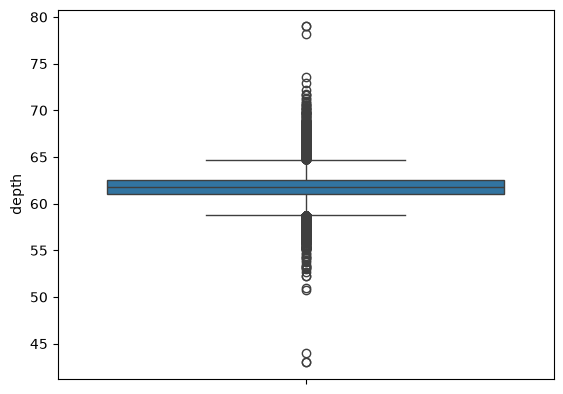

In [6]:
sns.boxplot(df,y="depth")

In [7]:
df["depth"].describe()

count    53940.000000
mean        61.749405
std          1.432621
min         43.000000
25%         61.000000
50%         61.800000
75%         62.500000
max         79.000000
Name: depth, dtype: float64

#### Count plot
 The frequency of each category in a categorical variable


Text(0.5, 1.0, 'table count plot')

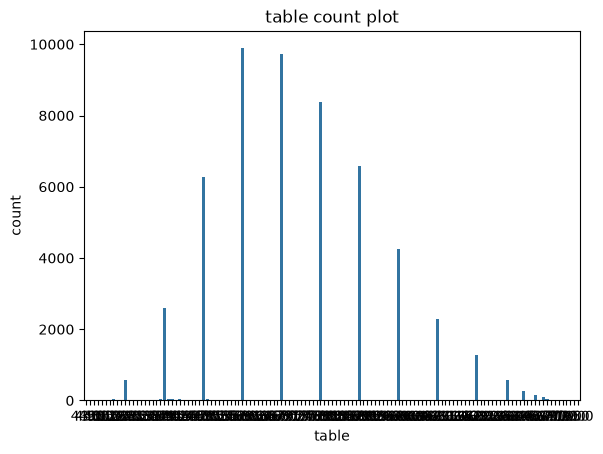

In [16]:
sns.countplot(df,x="table")
plt.title("table count plot")

Text(0.5, 1.0, 'carat distribution with countplot')

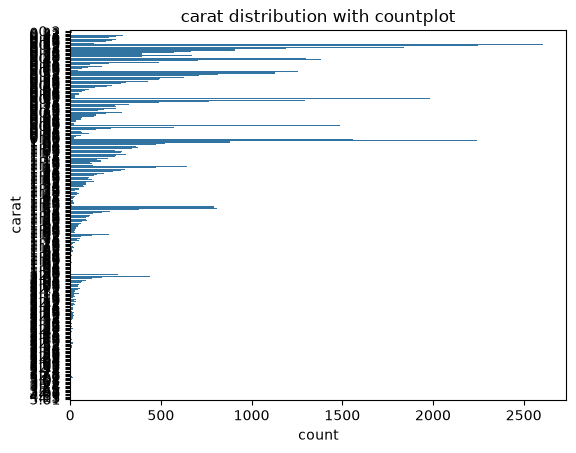

In [13]:
sns.countplot(df,y= "carat")
plt.title("carat distribution with countplot")

#### KDE plot
 A smoothed estimate of the distribution's shape

Text(0.5, 1.0, 'Price Distribution with kde')

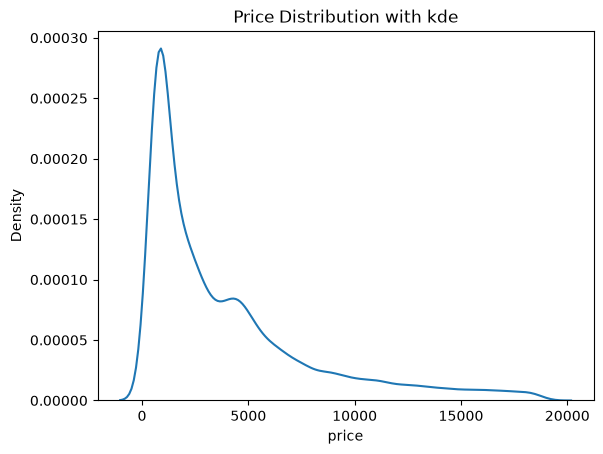

In [9]:
sns.kdeplot(df, x="price")
plt.title("Price Distribution with kde")

Text(0.5, 1.0, 'carat Distribution with kde')

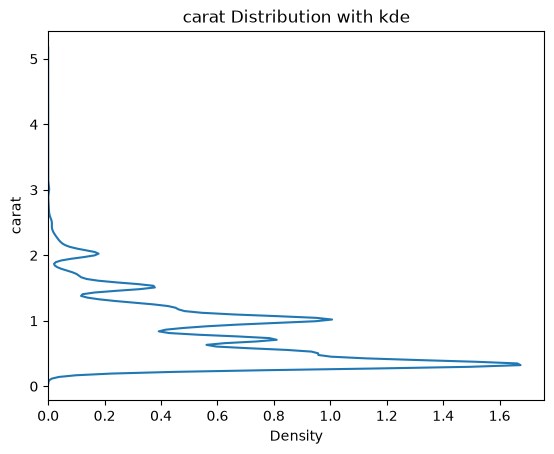

In [14]:
sns.kdeplot(df,y="carat")
plt.title("carat Distribution with kde")

### 4.4 Outlier Detection with the IQR Method
Outliers are values far outside the normal range — they can be genuine rare events or data-entry errors, and either
way they distort statistics and models. The standard IQR rule flags any value below Q1 - 1.5×IQR or above Q3 +
1.5×IQR as a potential outlier — exactly the values a box plot draws as individual points beyond its whiskers.

In [11]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1               : {Q1:.2f}")
print(f"Q3               : {Q3:.2f}")
print(f"IQR              : {IQR:.2f}")
print(f"Lower bound      : {lower_bound:.2f}")
print(f"Upper bound      : {upper_bound:.2f}")

outliers = df[(df["price"] < lower_bound) | (df["price"] > upper_bound)]
print(f"\nNumber of outliers found: {len(outliers)}")

Q1               : 950.00
Q3               : 5324.25
IQR              : 4374.25
Lower bound      : -5611.38
Upper bound      : 11885.62

Number of outliers found: 3540


" An outlier is a question, not a verdict: investigate whether it is a real value or an error before deciding to keep, cap, or 
remove it. Never delete outliers silently."

## Summary
content walkthrough , built on diamonds. It covers histogram, box plot, count plot, and KDE examples, plus an IQR calculation on price (Q1/Q3/bounds printed, no outlier count shown).

### Tools Used
Seaborn  •  Pandas  •  Matplotlib  •  Jupyter Notebook